### **MODEL FITNESS**

A gym branch that has developed customer interactions based on aligned data. The main objective is to define customer churn or the behavior of customers who stop using the gym services. 

Information Dataset: 
- data from the previous month

    - gender

    - Near_Location: whether the user lives or works in the neighborhood where the gym is located.

    - Partner: whether the user works for a partner company (the gym has partner companies whose employees receive discounts; in such cases, the gym stores information about customers’ employers).

    - Promo_friends: whether the user originally signed up through a “bring a friend” promotion (a friend’s promo code was used when paying for the first membership fee).

    - Phone — whether the user provided a phone number.

    - Age

    - Lifetime: the time (in months) since the user first joined the gym.

- Data of Visit, purchase, and current membership status data

    - Contract_period — 1 month, 3 months, 6 months, or 1 year.

    - Month_to_end_contract — the number of months remaining until the contract expires.

    - Group_visits — whether the user participates in group sessions.

    - Avg_class_frequency_total — average number of visits per week over the customer’s lifetime.

    - Avg_class_frequency_current_month — average number of visits per week during the current month.

    - Avg_additional_charges_total — total amount of money spent on additional gym services: café, sports goods, cosmetics, massages, etc.



In [2]:
import pandas as pd 
import numpy as np 
# train 
from sklearn.model_selection import train_test_split
# metrics 
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn import metrics 
# standar metric 
from sklearn.preprocessing import StandardScaler
# tool visialitaion 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#  library  color graphy 

title = {'fontsize': 14, 'fontweight': 'bold', 'color': 'black'}
subtitle = {'fontsize': 10, 'fontweight': 'normal', 'color': 'grey'}

## **EDA**

In [4]:
df = pd.read_csv(r'C:\Users\USUARIO\Desktop\TripleTen\Sprint_14\proyecto_14\gym_churn_us.csv')

In [5]:
df.sample(5)

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
3361,0,1,0,0,1,12,0,29,311.457400,12.0,3,1.717239,1.582191,0
352,1,0,0,0,1,1,1,28,209.338849,1.0,3,3.787758,3.680692,0
822,0,1,1,1,1,1,1,29,460.904008,1.0,10,3.157764,3.154869,0
1432,0,0,0,0,1,1,0,32,160.774616,1.0,0,0.668279,0.000000,1
3205,1,1,0,0,1,1,0,23,87.047265,1.0,0,2.047669,1.111466,1


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gender,4000.0,0.510250,0.499957,0.000000,0.000000,1.000000,1.000000,1.000000
Near_Location,4000.0,0.845250,0.361711,0.000000,1.000000,1.000000,1.000000,1.000000
Partner,4000.0,0.486750,0.499887,0.000000,0.000000,0.000000,1.000000,1.000000
Promo_friends,4000.0,0.308500,0.461932,0.000000,0.000000,0.000000,1.000000,1.000000
Phone,4000.0,0.903500,0.295313,0.000000,1.000000,1.000000,1.000000,1.000000
Contract_period,4000.0,4.681250,4.549706,1.000000,1.000000,1.000000,6.000000,12.000000
Group_visits,4000.0,0.412250,0.492301,0.000000,0.000000,0.000000,1.000000,1.000000
Age,4000.0,29.184250,3.258367,18.000000,27.000000,29.000000,31.000000,41.000000
Avg_additional_charges_total,4000.0,146.943728,96.355602,0.148205,68.868830,136.220159,210.949625,552.590740
Month_to_end_contract,4000.0,4.322750,4.191297,1.000000,1.000000,1.000000,6.000000,12.000000


According to the data, we had tree columns thah we need to adjustment to avoid overfiting:

    - Age
    - Avg_additional_charges_total
    - Lifetime 
    - Contract_period
    - Avg_class_frequency_total
    - Avg_class_frequency_current_month

observation values for Churn:

In [8]:
mean_values = (
    df
    .groupby('Churn')
    .mean()
    .round(2)
)

mean_values

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.51,0.87,0.53,0.35,0.9,5.75,0.46,29.98,158.45,5.28,4.71,2.02,2.03
1,0.51,0.77,0.36,0.18,0.9,1.73,0.27,26.99,115.08,1.66,0.99,1.47,1.04


### Histogram Contract month

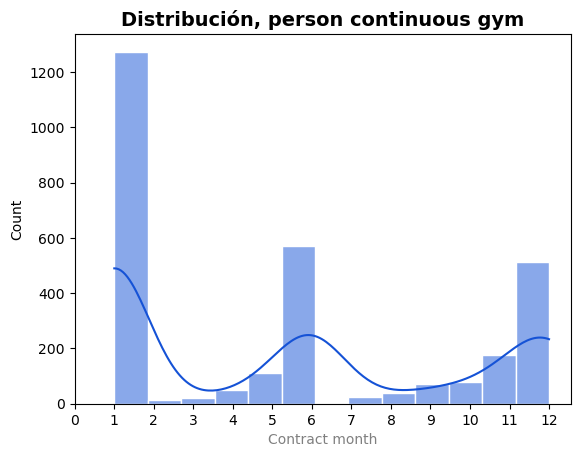

In [9]:
churn_0 = df.query('Churn == 0')
plt.Figure(figsize = (10,6))
sns.histplot(data = churn_0, x = 'Month_to_end_contract', color="#1552D6FF",  kde = True, edgecolor = 'white')
plt.title('Distribución, person continuous gym',fontdict=title)
plt.xlabel('Contract month', fontdict=subtitle)
plt.xticks(np.arange(0,13,1))
plt.show()


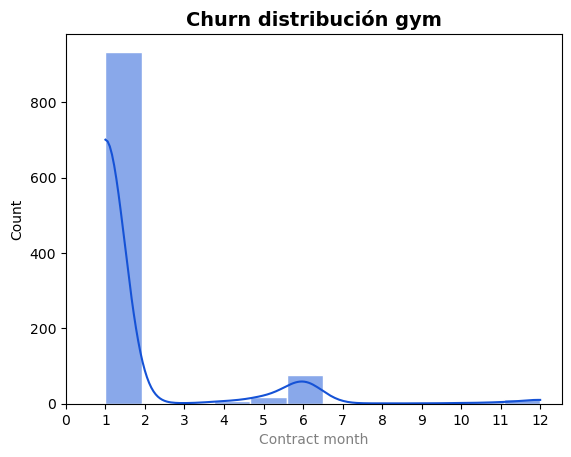

In [10]:
churn_1 = df.query('Churn == 1')
plt.Figure(figsize = (10,6))
sns.histplot(data = churn_1, x = 'Month_to_end_contract', color="#1552D6FF",  kde = True, edgecolor = 'white' )
plt.title('Churn distribución gym', fontdict= title)
plt.xlabel('Contract month', fontdict=subtitle)
plt.xticks(np.arange(0,13,1))
plt.show()

### Correlation

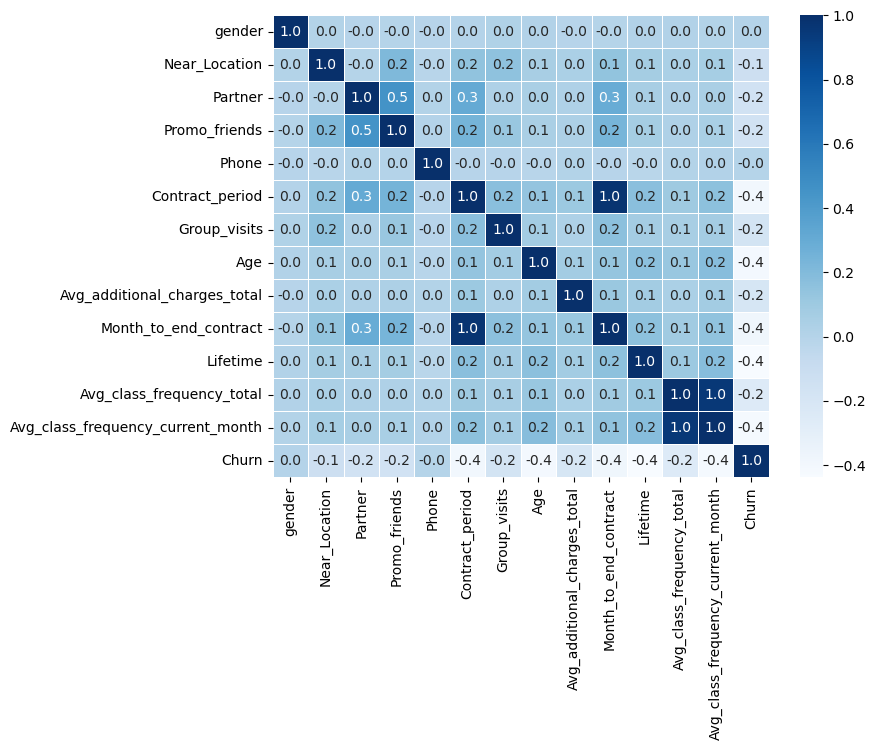

In [11]:
corr = df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    edgecolor = 'white',
    linewidths= 0.6

)

plt.show()

### **Perfomance model**

before to procide the model, on the dataframe it's identify the data had a binaty and numeric information. First select the numeric values to standarice on join white the binary values to worck.

In [12]:
# split binary and numeric 
df_numeric  = df[['Age','Avg_additional_charges_total','Lifetime','Contract_period', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']]
df_binary = df[['gender','Near_Location','Partner','Promo_friends','Phone','Group_visits']]

scaler_df = StandardScaler()
scaler_df.fit(df_numeric)
df_sc= pd.DataFrame(scaler_df.transform(df_numeric.values), columns=df_numeric.columns)
df_ = pd.concat([df_sc, df_binary], axis= 1)
df_


c:\Users\USUARIO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


,Age,Avg_additional_charges_total,Lifetime,Contract_period,Avg_class_frequency_total,Avg_class_frequency_current_month,gender,Near_Location,Partner,Promo_friends,Phone,Group_visits
0,-0.056554,-1.377531,-0.193329,0.289890,-1.911920,-1.678472,1,1,1,1,0,1
1,0.557327,-0.350213,0.873680,1.608822,0.045176,0.136014,0,1,0,0,1,1
2,-0.363494,-0.181592,-0.460081,-0.809219,-0.020493,-0.029019,0,1,1,0,1,0
3,1.171208,-0.874722,-0.460081,1.608822,1.364655,1.510450,0,1,1,1,1,1
4,-0.977375,0.533700,-0.193329,-0.809219,-0.787076,-0.614542,1,1,1,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1.171208,-1.500232,1.140432,1.608822,0.417105,0.552842,1,1,1,0,1,0
3996,-0.056554,-0.810225,-0.726833,-0.809219,-0.619110,-1.400294,0,1,0,0,1,1
3997,-0.363494,-0.713002,-0.460081,1.608822,0.933139,1.011031,1,1,1,1,1,0
3998,0.864268,-0.882582,-0.193329,0.289890,-0.256049,-0.162252,0,1,1,1,1,0


#### Logistic regression

In [13]:
# Data Preprocessing
x = df.drop('Churn', axis = 1)
y = df['Churn']

x_train, x_test, y_train, y_test = train_test_split( x, y , test_size = 0.2)

# Model logidstic regression

from sklearn.linear_model import LogisticRegression 
model = LogisticRegression(random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)


## Evaluación del modelo
def  report (y_test, y_pred):
    print('Evaluation metrics')
    print('MAE :{:.2f}'.format(mean_absolute_error(y_test, y_pred)))
    print('MSE : {:.2f}'.format(mean_squared_error(y_test,y_pred)))
    print('R2 Score: {:.2f}'.format(r2_score(y_test,y_pred)))
    info =metrics.classification_report(y_test, y_pred)
    print(info)
    cm = metrics.confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted', fontdict=subtitle)
    plt.ylabel('Actual', fontdict=subtitle)
    plt.title('Confusion Matrix')
    plt.show();




c:\Users\USUARIO\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Evaluation metrics
MAE :0.08
MSE : 0.08
R2 Score: 0.58
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       599
           1       0.93      0.75      0.83       201

    accuracy                           0.92       800
   macro avg       0.92      0.86      0.89       800
weighted avg       0.92      0.92      0.92       800



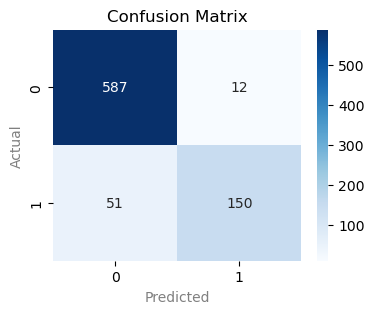

In [14]:
report(y_test, y_pred)  

According to the metrics obtained from the logistic regression model, we can observe the following results:

- Confusion matrix: The model correctly identified 580 true positives, representing clients who continue using the gym services. On the other hand, there are 162 false negatives, corresponding to clients who churned.
- Accuracy: The model achieved an accuracy of 93%, indicating a high overall performance.
- Precision: The model reached a 94% precision in identifying clients who continue using the gym services, meaning that most of the clients predicted as active are actually retained.
- recision and recall: The precision and recall metrics show good consistency, suggesting a balanced and reliable classification performance.

#### Random Forest 

Evaluation metrics
MAE :0.10
MSE : 0.10
R2 Score: 0.47
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       599
           1       0.91      0.67      0.77       201

    accuracy                           0.90       800
   macro avg       0.90      0.82      0.85       800
weighted avg       0.90      0.90      0.89       800



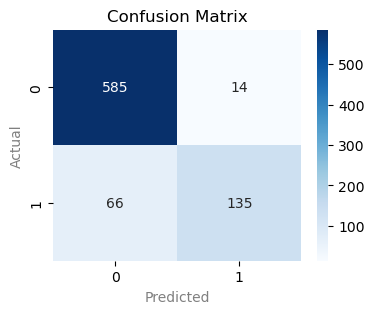

In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators = 100,
                                max_depth=5,
                                criterion = 'gini',
                                max_features = 'sqrt',
                                random_state=42
                                )
rf_model.fit(x_train, y_train)

y_pred_rf = rf_model.predict(x_test)
report(y_test, y_pred_rf)



Random forest model present the new results:
- Confusion matrix: The model correctly identified 574 true positives, representing clients who continue using the gym services. Additionally, 145 false negatives correspond to clients who no longer use the gym services but were incorrectly classified as active.
- Accuracy: The Random Forest model achieved an accuracy of 90%, indicating strong overall performance.
- Precision: The model reached a 93% precision in identifying clients who are likely to continue as customers.
- The balance between precision and recall resulted in a 94% score, showing a consistent and reliable classification performance.

______

## Unsupervised learning


normalizate a group of obervation on per features basis
Before rennuning K-mean and linkage, it is beneficial to rescale each feature dimension of the observation set by its standar desviation ( WHITHEN "Whit noise" where each frequency has equal power)

In [16]:
from scipy.cluster.vq import whiten 
whiten_numeric = pd.DataFrame(
    data = whiten(
        obs = df,
        check_finite = True
    ),
    columns= df.columns
)
whiten_numeric.index = df.index
df_st_ns = whiten_numeric

In [17]:
for j in df_st_ns.columns:
    print(j, df_st_ns[j].std())
    

gender 1.0001250234423746
Near_Location 1.0001250234424188
Partner 1.0001250234423797
Promo_friends 1.0001250234424357
Phone 1.0001250234423849
Contract_period 1.0001250234424046
Group_visits 1.0001250234424184
Age 1.0001250234423953
Avg_additional_charges_total 1.0001250234423829
Month_to_end_contract 1.000125023442373
Lifetime 1.000125023442381
Avg_class_frequency_total 1.0001250234423844
Avg_class_frequency_current_month 1.0001250234423835
Churn 1.0001250234424066


### Linkage

In [18]:
from scipy.spatial.distance import pdist 

dict_pdist = {}
list_metric = [
    'braycurtis',  'cityblock', 'correlation', 'cosine', 'mahalanobis', 'euclidean'
]
for j in list_metric:
    dict_pdist[j] = pdist( X = df_st_ns, metric=j)

In [19]:
from scipy.cluster.hierarchy import linkage, dendrogram
dict_linkage = {}
list_method = ['average', 'ward']

for j in list_method:
    for k in list_metric:
        dict_linkage[j+'_'+k] = linkage(
            y=dict_pdist[k],
            method=j
        )


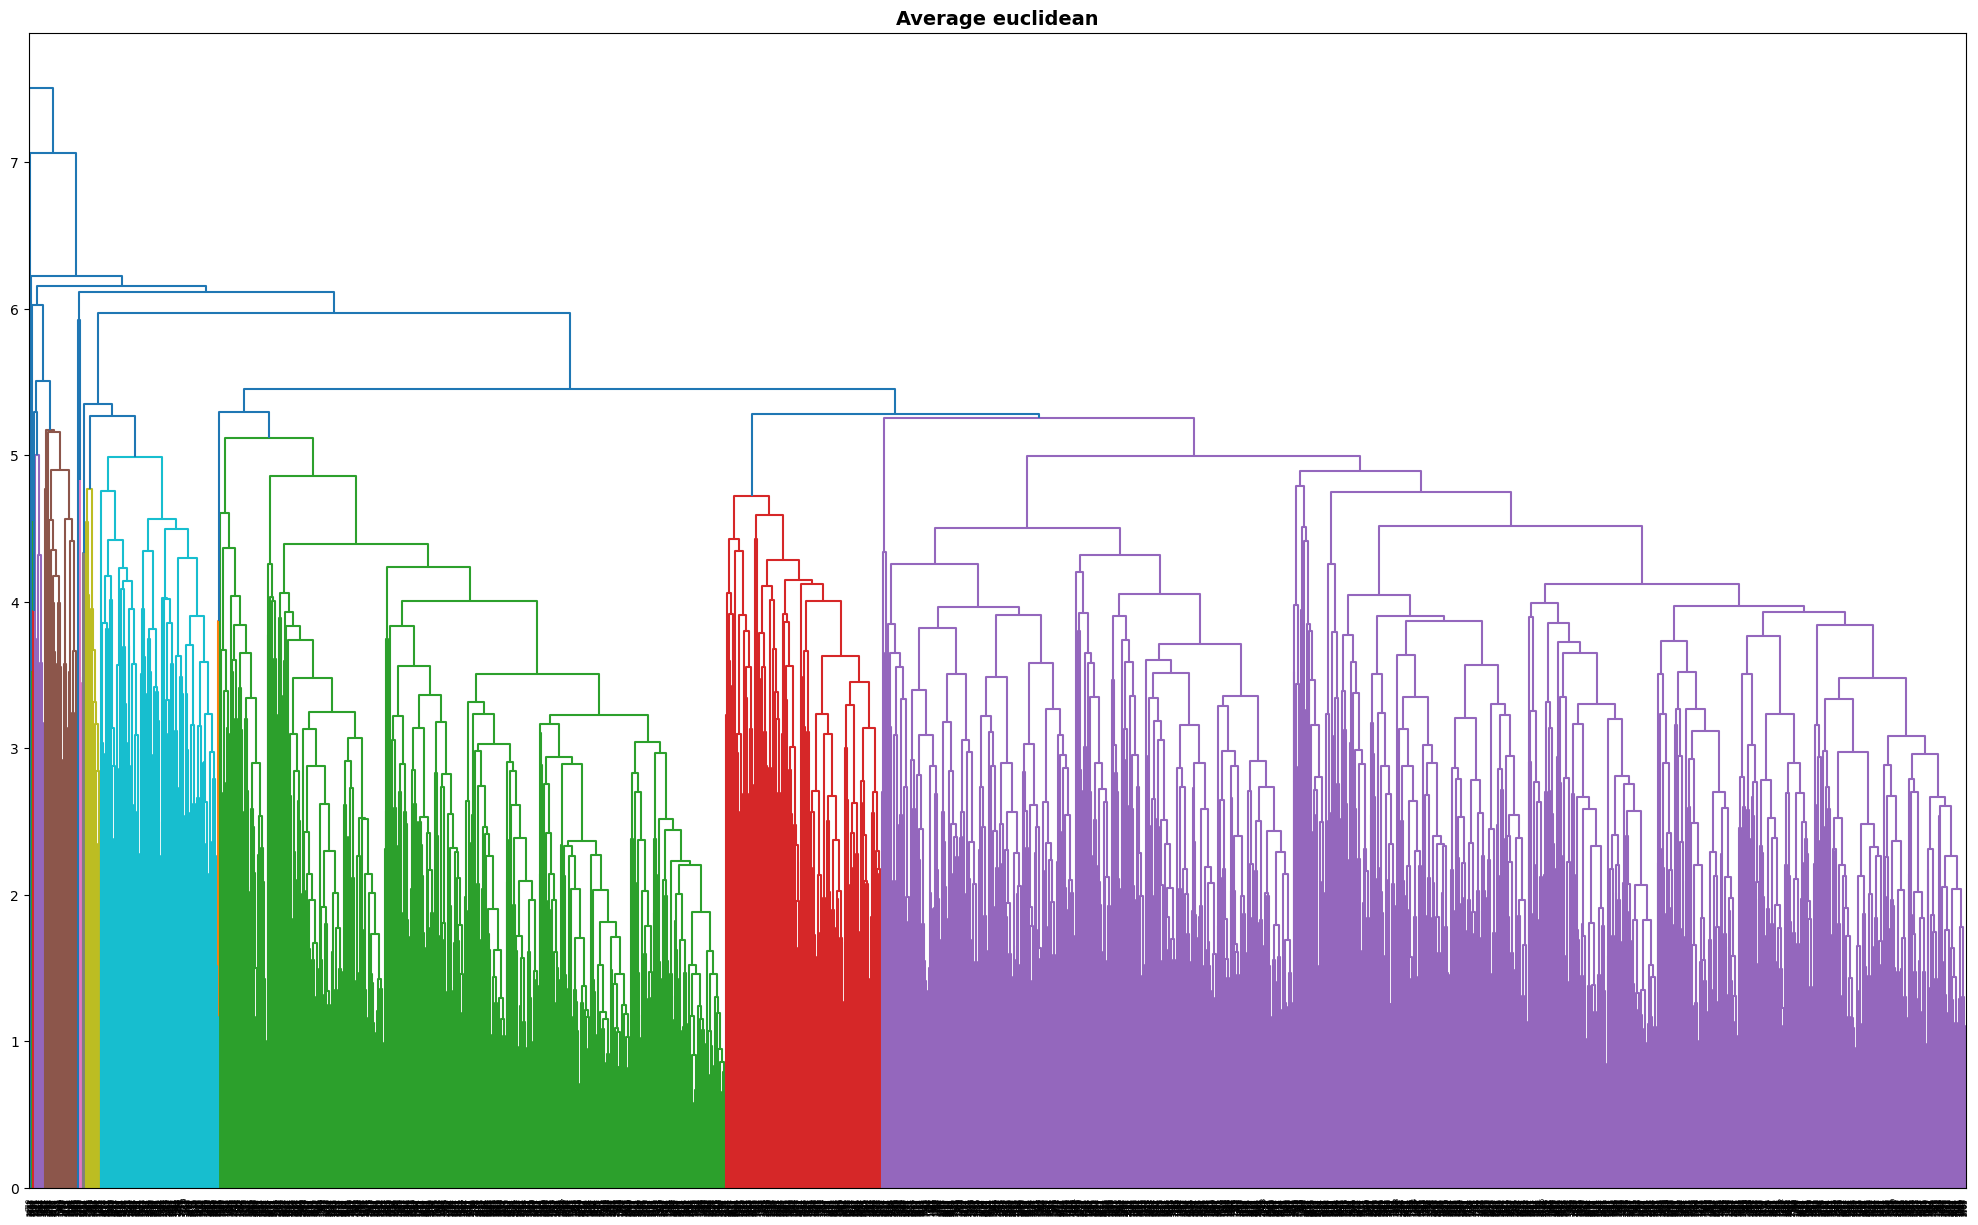

In [20]:
fig = plt.figure(figsize = (25,15))
plt.title('Average euclidean', fontdict= title)
dendrogram(
    Z = dict_linkage['average_euclidean'],
    labels = df_st_ns.index,
    count_sort= True, 
    distance_sort = True,
    
);

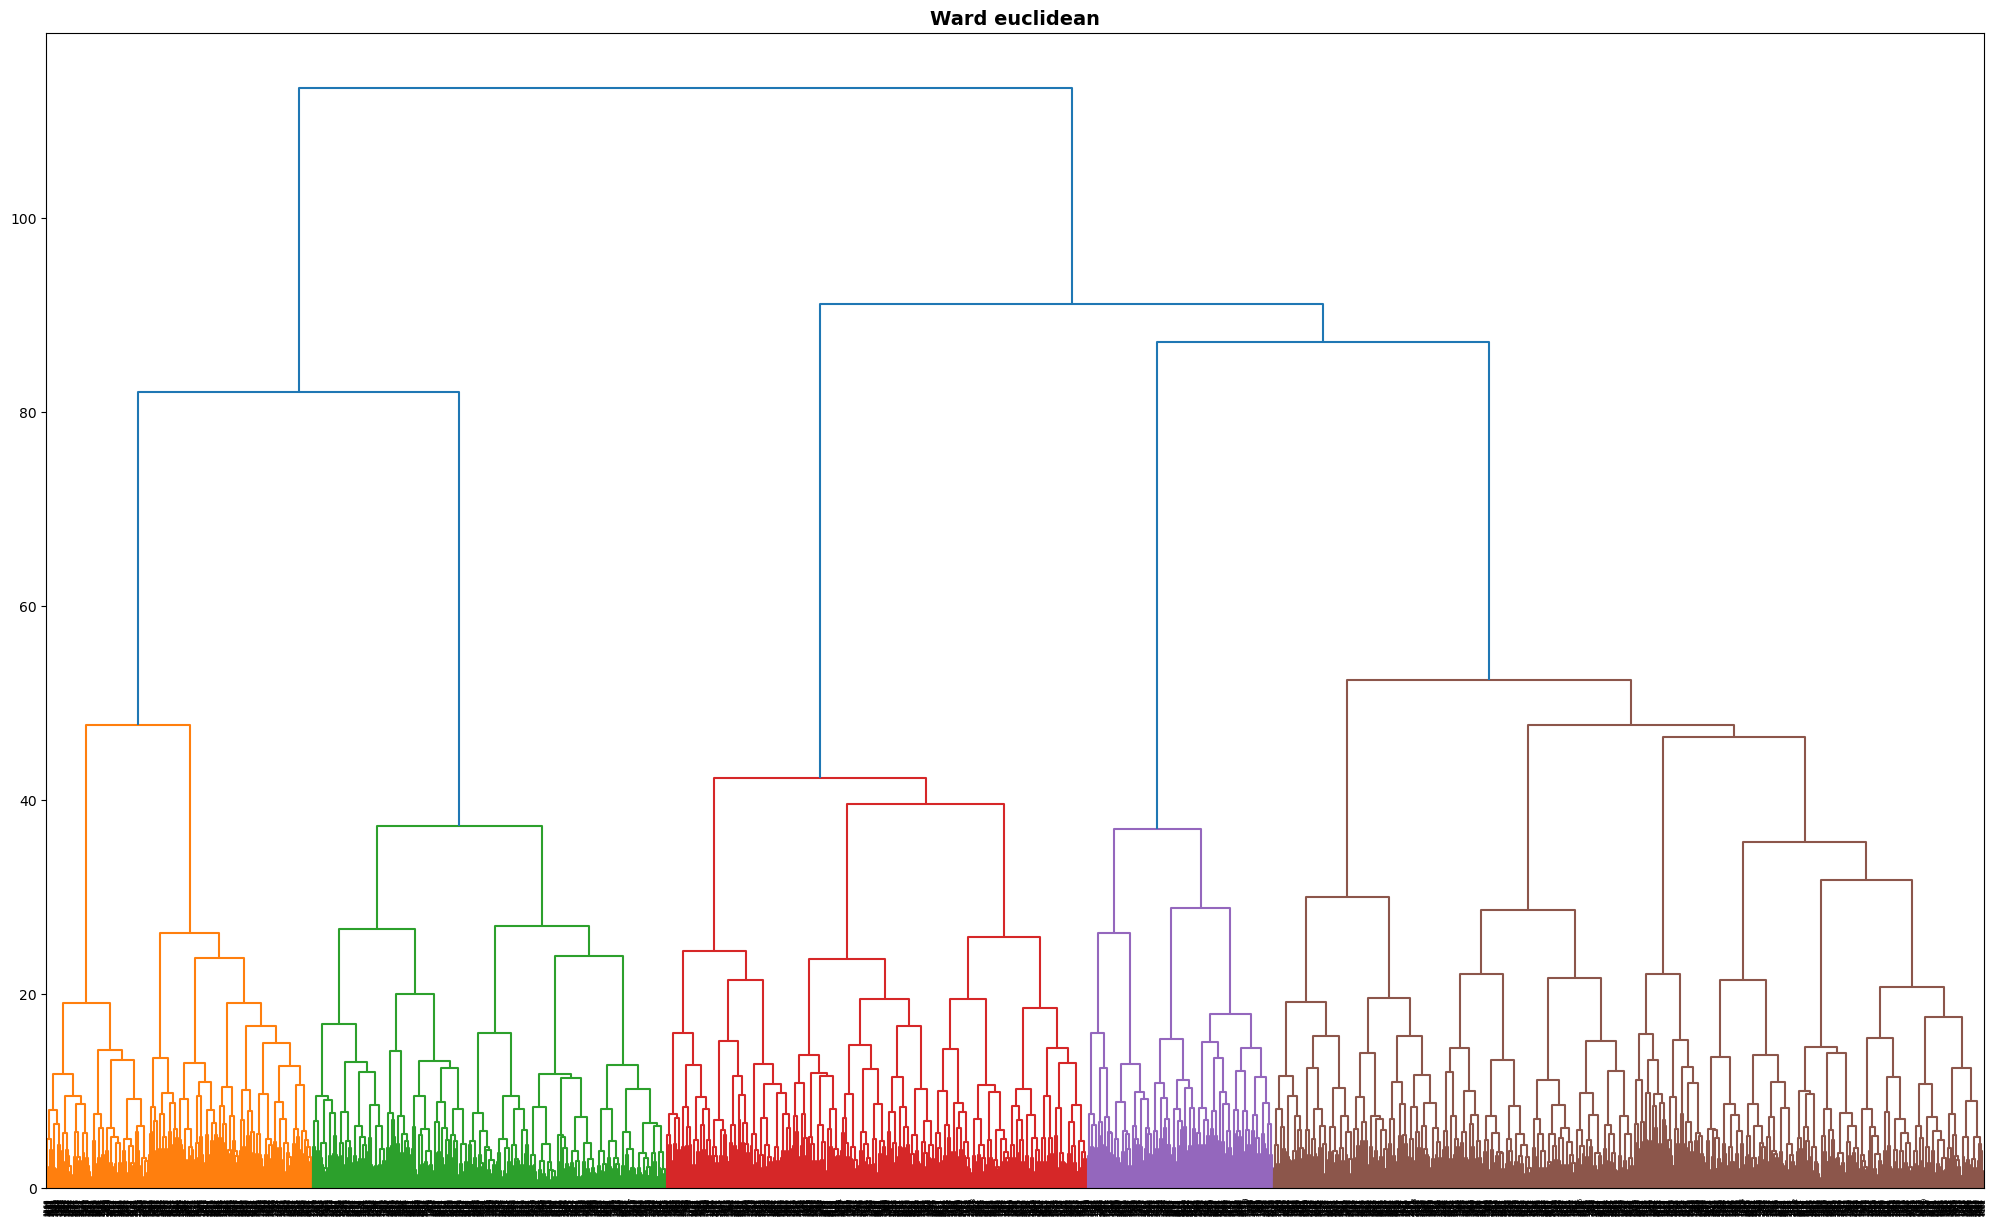

In [21]:
fig = plt.figure(figsize = (25,15))
plt.title('Ward euclidean', fontdict= title)
dendrogram(
    Z = dict_linkage['ward_euclidean'],
    labels = df_st_ns.index,
    count_sort= True, 
    distance_sort = True,
    
);

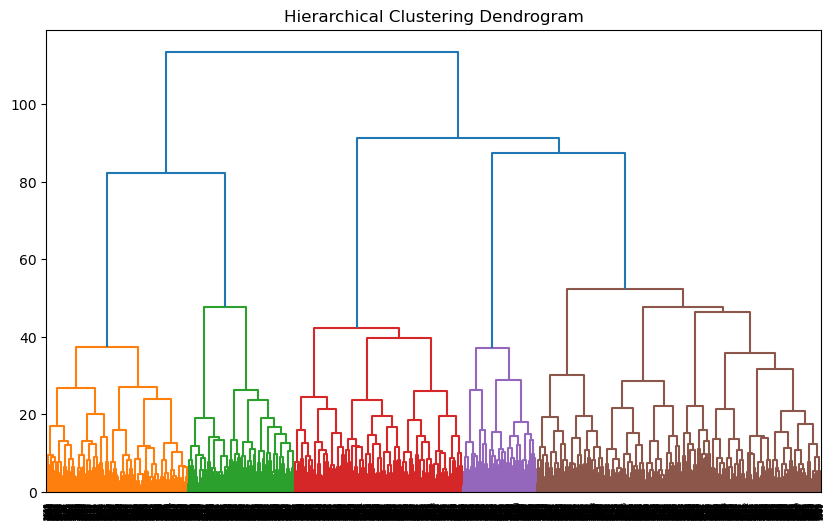

In [22]:
from scipy.cluster.hierarchy import linkage, dendrogram
Z = linkage(df_st_ns, method='ward' )
plt.figure(figsize=(10, 6))
dendrogram(Z)
plt.title('Hierarchical Clustering Dendrogram')
plt.show()


____

### K-Means

In [26]:

from sklearn.cluster import KMeans 

kmeans = KMeans(n_clusters=5, random_state= 42).fit(df_st_ns.values)

df_st_ns["cluster"] = kmeans.labels_


In [27]:
cluster_inf = df_st_ns.groupby('cluster').mean().round(2)
cluster_inf

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
cluster,,,,,,,,,,,,,,
0,1.02,2.76,0.67,0.49,3.39,0.36,0.58,8.26,1.19,0.38,0.28,1.44,0.96,2.11
1,1.01,2.64,1.57,1.24,3.39,2.34,1.11,9.17,1.66,2.31,1.23,2.06,1.90,0.03
2,1.03,2.76,0.67,0.48,3.39,0.50,0.91,9.27,1.67,0.51,1.30,2.19,2.03,0.01
3,1.05,2.39,0.94,0.66,0.00,1.05,0.87,8.99,1.50,1.07,1.05,1.91,1.64,0.60
4,1.00,0.00,0.92,0.17,3.39,0.50,0.44,8.77,1.41,0.52,0.76,1.78,1.48,0.98


In [28]:
cancel = df_st_ns.groupby(['cluster','Churn']).size().unstack()
cancel

Churn,0.000000,2.265179
cluster,,
0,52,715
1,1079,15
2,1232,4
3,283,103
4,293,224


Most clusters show strong customer loyalty, especially Cluster 3, which has almost no churn. Clusters 0 and 4 are also stable with high retention. Cluster 2 presents moderate risk, while Cluster 1 has very high churn and represents the main group of customers leaving.


In [45]:
def graphy(data_, columna):

    for col in data_.columns:
        if col == columna:
            continue
        plt.Figure(figsize=(5,4))
        if data_[col].nunique() <= 2:
            sns.countplot(data= data_, x = col, hue = columna, palette='Blues')
            plt.xlabel(f'{col}',fontdict = subtitle)
        else:
            sns.histplot(data = data_, x = col, hue= columna, alpha=0.5, palette='Blues',edgecolor="white", linewidth=1)
            plt.xlabel(f'{col}', fontdict=subtitle)

        plt.title(f'{col} per {columna}', fontdict=title)
        plt.tight_layout()
        plt.show()



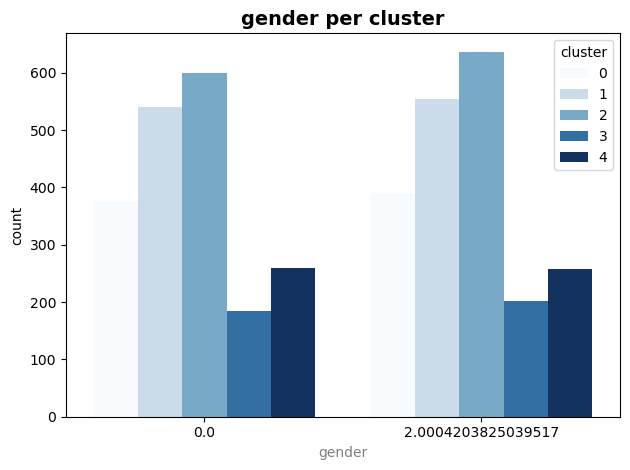

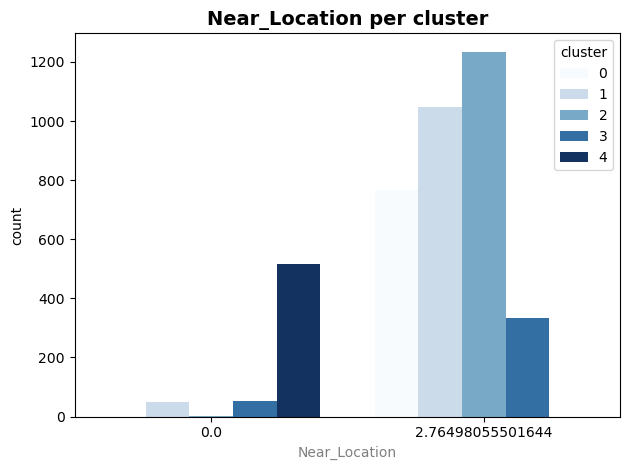

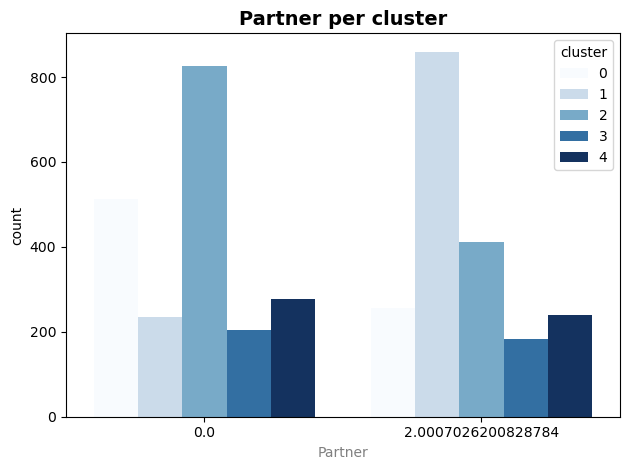

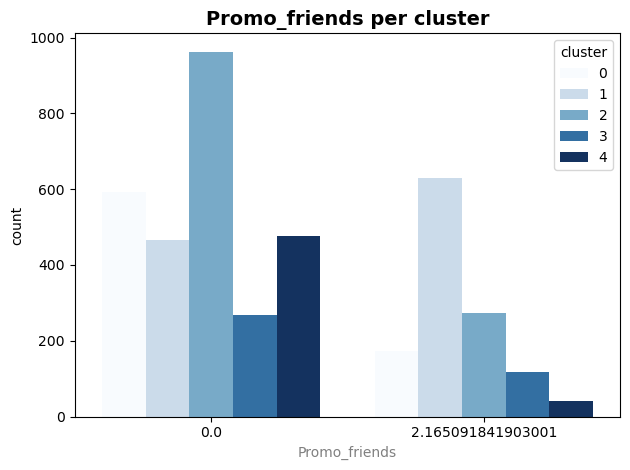

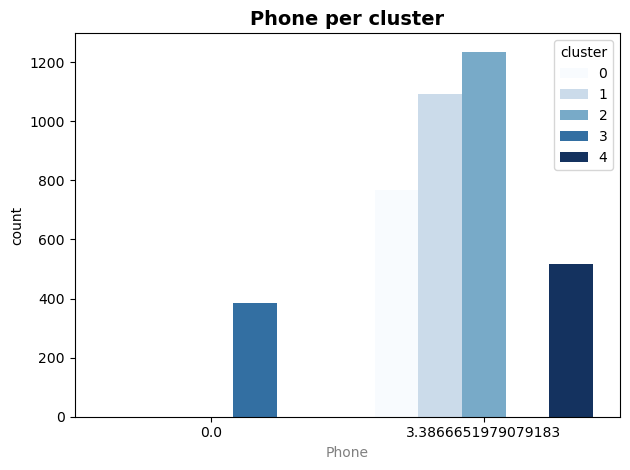

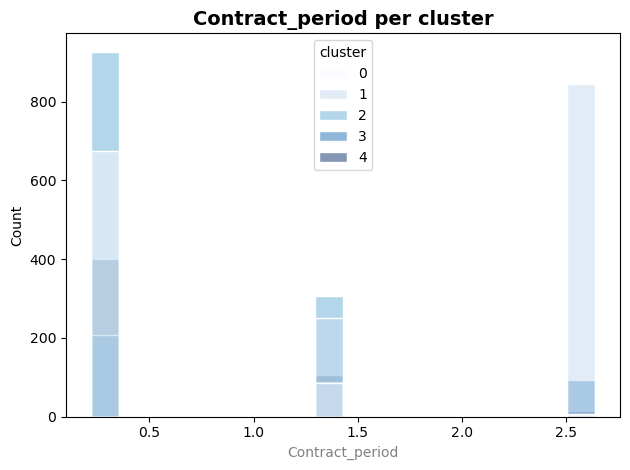

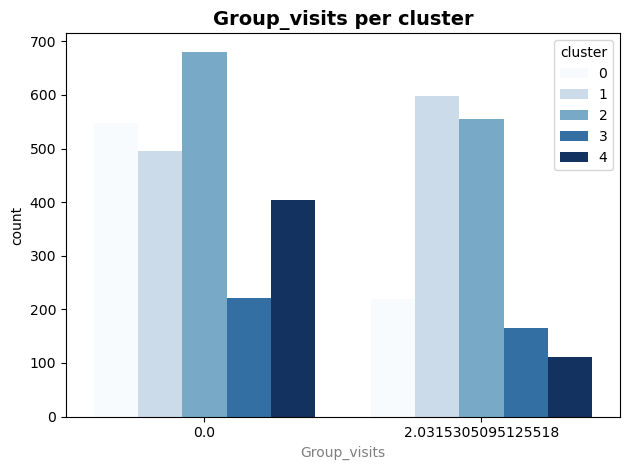

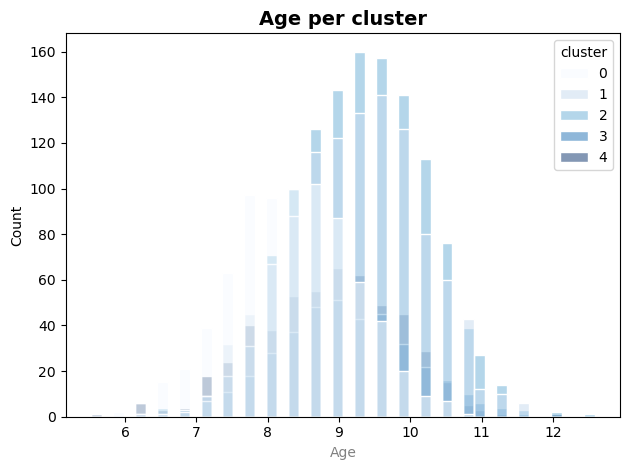

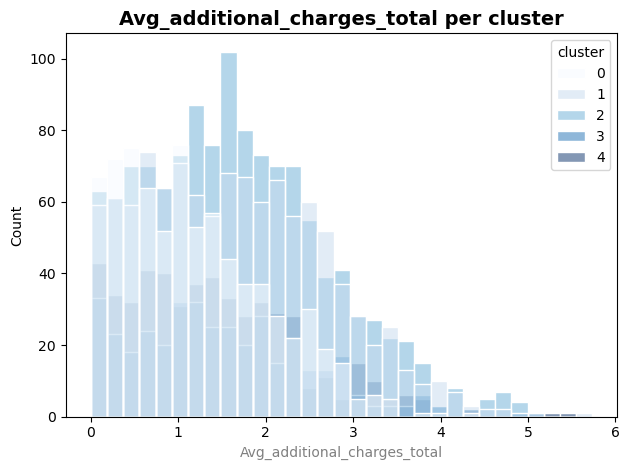

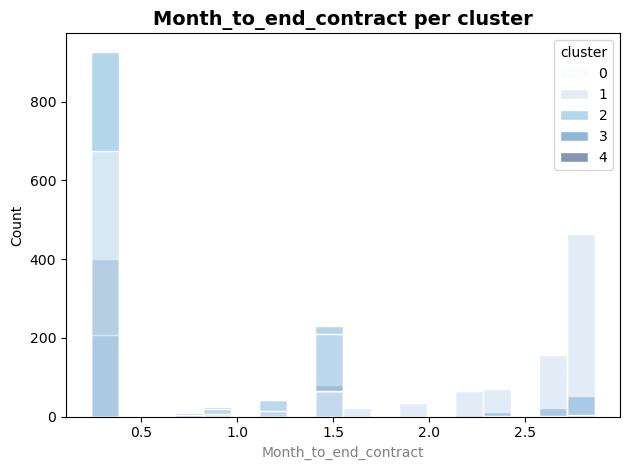

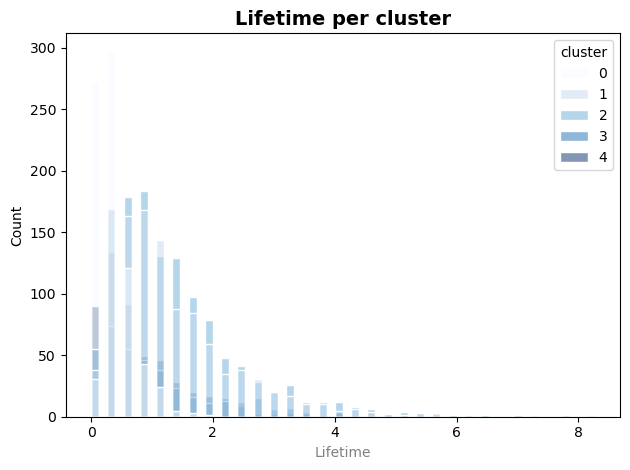

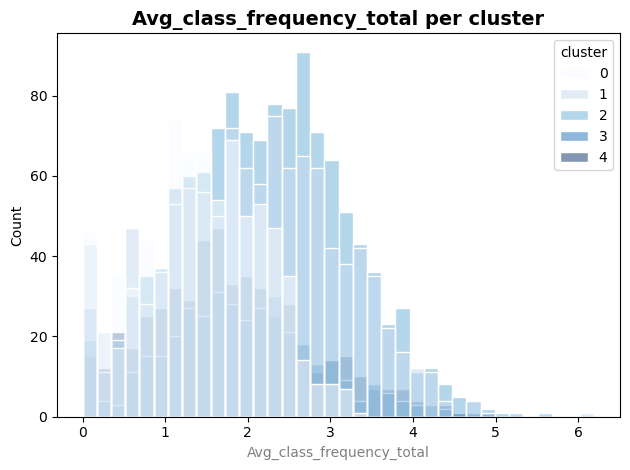

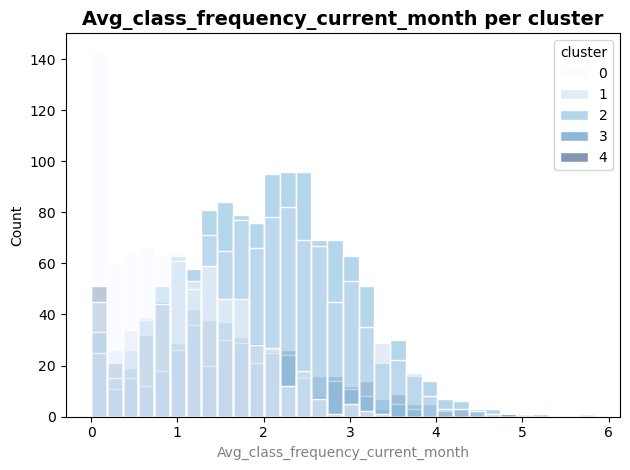

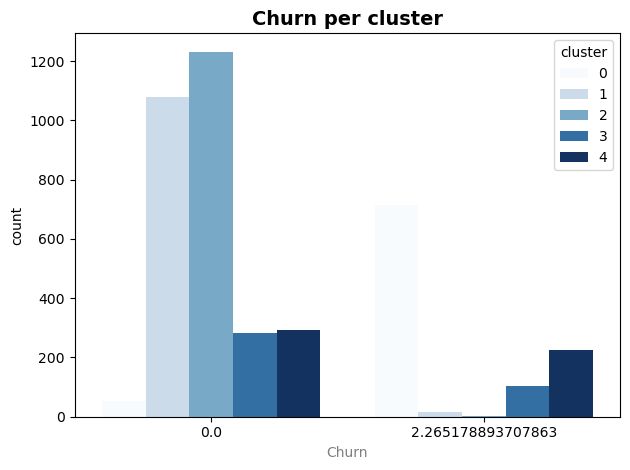

In [46]:
graphy(df_st_ns ,'cluster')

______

## **Resumi**




first clean database, look for missing values, and duplicates

to understand the information, identify mean, max, min and also visualization histograms Distribution, person continuous membership to the gym, and the ones that churn. furthermore to understand more the relation between the qualities on the dataset, it generate a correlation matrix to identify:

Strong correlation = 1.0:
- contract period with month to end contract
- avg class frequency total with avg class frequency current month

Medium correlation > 0.5 :
- partner with promo Friends

for performance model before start, it is important to notice that the dataframe count with binary and numeric values where is needed to standard values, first we define the binary and numeric values use StandardScaler and at the end as result concat tables. to avoid overfitting. with an appropriate table to work it able to apply model as logistic regression, random forest and metrics to evaluate results.

**Unsupervised learning**

To normalize a group of observations on a per-feature basis, it is important to scale each feature so that they are comparable. Before running algorithms such as K-Means clustering or hierarchical clustering (linkage), it is beneficial to rescale each feature dimension by its standard deviation. This process, known as whitening (or “white noise” transformation), ensures that each feature contributes equally to the analysis by removing differences in scale and variance.

case k-means:

a) Cluster 0:

- Churn: 0.02
- Long contracts (1.72)
- High tenure (1.96)
- Good attendance level
- High proportion with Partner and promotions
Defined as a stable client

b) Cluster 1:

- Churn: 0.84
- Very short contracts (0.33)
- Low tenure (1.19)
- Low attendance
- Weak social connection
Defined as a high-risk client

c) Cluster 2:

- Churn: 0.19
- Short-to-medium contracts
- Acceptable attendance
- Average tenure
Defined as moderate risk

d) Cluster 3:

- Churn: 0.01
- Very high attendance (2.55 / 2.69)
- High monthly frequency (2.48)
- Strong social connection (Partner, Promo_friends)
- Relatively long contracts
Defined as loyal clients VIP

e) Cluster 4:

- Churn: 0.04
- Very high monthly attendance
- Average contracts
- Good tenure
Defined as long-standing clients

    

_____________

## **Conclusions**

- the person that going to the gym are split in two semesters, without count the first month of the year present growth until Jun and on July decrease and continue growth to the end of the year, on the other hand, the churn distribution show increase and decrease on minor scale also at the end of the second semester Jun.

- The logistic regression model identified 580 true positives, which represent clients who are still using the gym services. Additionally, there were 162 false negatives, corresponding to clients who left the gym but were incorrectly classified. achieved an accuracy of 93%, indicating a high level of overall performance in distinguishing between active and inactive clients. Furthermore, the recall for the positive class is 97%, meaning that the model successfully detects most clients who continue using the gym services, precision of 94% for the positive class. This implies that when the model predicts a client will remain active. Regarding error metrics, the Mean Absolute Error (MAE) of 7% indicates that the predicted probabilities differ from the actual outcomes by about 7% on average, suggesting accurate probability estimates. Similarly, the Mean Squared Error (MSE) of 0.07 shows that large prediction errors are relatively uncommon. coefficient of determination of 62% of the variability in client behavior. demonstrates strong predictive performance, with high accuracy, precision, and recall in identifying active gym clients. The relatively low error metrics indicate reliable probability estimates, and the coefficient of determination value shows moderate explanatory power. Although the model performs well for practical decision-making, further improvements could be achieved by incorporating additional relevant features to better capture the remaining unexplained variation in customer behavior.

- Random Forest model present that was train with the next parameters n_estimators = 100, max_depth=5, criterion = 'gini', max_features = 'sqrt', random_state=42. Evaluate the confusion matrix, true positive 574 clients are using the gym services and false negatives 145 clients that churn the services. The Random Forest model achieved an accuracy of 90%, indicating strong overall performance. The model reached a 93% precision in identifying clients who are likely to continue as customers. recall resulted in a 94% score, showing a consistent and reliable classification. The mean absolute error predicted probabilities differ from reality by about 10% on average. Mean squared error 10% and the model just explain 47% variance in the target. Meaning that more than half of the variation is influenced by factors not captured by the model. Overall, the model provides moderately accurate predictions but has limited explanatory power and could be improved by incorporating additional relevant features or using a more advanced modeling approach.

- Unsupervised learning using k-means model with identify the type of cluster, cancellation (churn) and relate with other characteristics: Customers with long contracts, high attendance, strong social connections, and longer tenure show very low churn and represent the gym’s most valuable segments (Clusters 0, 3, and 4), while clients with short contracts, low participation, weak engagement, and short membership duration are far more likely to cancel, as seen in Cluster 1. Cluster 2 represents a moderate-risk group that could be retained with targeted actions. Overall, retention is primarily driven by commitment length, usage frequency, and social integration within the gym.